In [1]:
import os
import glob
import json
import random
import datetime
import re
import cv2
import math
from typing import List, Optional, Dict, Any, Tuple

import numpy as np
from pathlib import Path

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, IterableDataset, TensorDataset
from torchvision import transforms

import matplotlib.pyplot as plt
from PIL import Image

from scipy.stats import ttest_ind

from captum.concept import TCAV, Concept, Classifier
from captum.attr import LayerGradientXActivation, LayerIntegratedGradients
from captum.concept._utils.data_iterator import dataset_to_dataloader, CustomIterableDataset
from captum.concept._utils.common import concepts_to_str


from model.model_dylan import FlexibleTNet
from model.model_sq import TNet
from tools import plotting, metrics, model_io, tcav, data, utils
from tools.plotting import plot_concepts



/opt/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
import json
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch


# ------------------------------------------------------------
# 1️⃣ Load and merge both label files
# ------------------------------------------------------------
gt_train = os.path.join("./data", "gt_train_discrete.json")
gt_val   = os.path.join("./data", "gt_val_discrete.json")

with open(gt_train, "r") as f:
    labels_train = json.load(f)

with open(gt_val, "r") as f:
    labels_val = json.load(f)

# We have 50,000 images in train folder and 2,000 in val folder
# Merge the first 50,000 train labels + first 2,000 val labels
labels = labels_train[:50000] + labels_val[:2000]
print(f"Total samples available: {len(labels)} (50,000 train + 2,000 val)")

# ------------------------------------------------------------
# 2️⃣ Create 80/20 split from all available data
# ------------------------------------------------------------
all_indices = list(range(len(labels)))
train_idx, val_idx = train_test_split(
    all_indices, test_size=0.2, random_state=42, stratify=labels
)

print(f"Train split: {len(train_idx)} samples | Val split: {len(val_idx)} samples")

# ------------------------------------------------------------
# 3️⃣ Define dataset class with proper folder mapping
# ------------------------------------------------------------
class AixiShapeDataset(Dataset):
    def __init__(self, root_dir, indices, all_labels, transform=None):
        """
        Args:
            root_dir: base directory (e.g., "./data/aixi_shape")
            indices: list of indices to use from all_labels
            all_labels: complete list of labels (0-51999)
            transform: image transformations
        """
        self.root_dir = root_dir
        self.indices = indices
        self.all_labels = all_labels
        self.transform = transform
        self.train_size = 50000  # Images 0-49999 are in train/, 50000-51999 in val/

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        
        # Map global index to correct folder and local filename
        if real_idx < self.train_size:
            # Images 0-49999 are in train/ folder
            img_path = os.path.join(self.root_dir, "train", f"{real_idx:05d}.png")
        else:
            # Images 50000-51999 are in val/ folder as 00000-01999
            local_idx = real_idx - self.train_size
            img_path = os.path.join(self.root_dir, "val", f"{local_idx:05d}.png")
        
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = int(self.all_labels[real_idx])
        return image, label

# ------------------------------------------------------------
# 4️⃣ Define transforms and dataloaders
# ------------------------------------------------------------
root_dir = "./data/aixi_shape"

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

trainset = AixiShapeDataset(root_dir=root_dir, indices=train_idx, all_labels=labels, transform=transform)
valset   = AixiShapeDataset(root_dir=root_dir, indices=val_idx, all_labels=labels, transform=transform)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
valloader   = DataLoader(valset, batch_size=128, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Total samples available: 52000 (50,000 train + 2,000 val)
Train split: 41600 samples | Val split: 10400 samples
Using device: cpu


In [3]:
# Datasets are already created in the previous cell
# trainset and valset (testset) are ready to use

print(f"Train samples: {len(trainset)}, Val samples: {len(valset)}")

Train samples: 41600, Val samples: 10400


Training set samples:


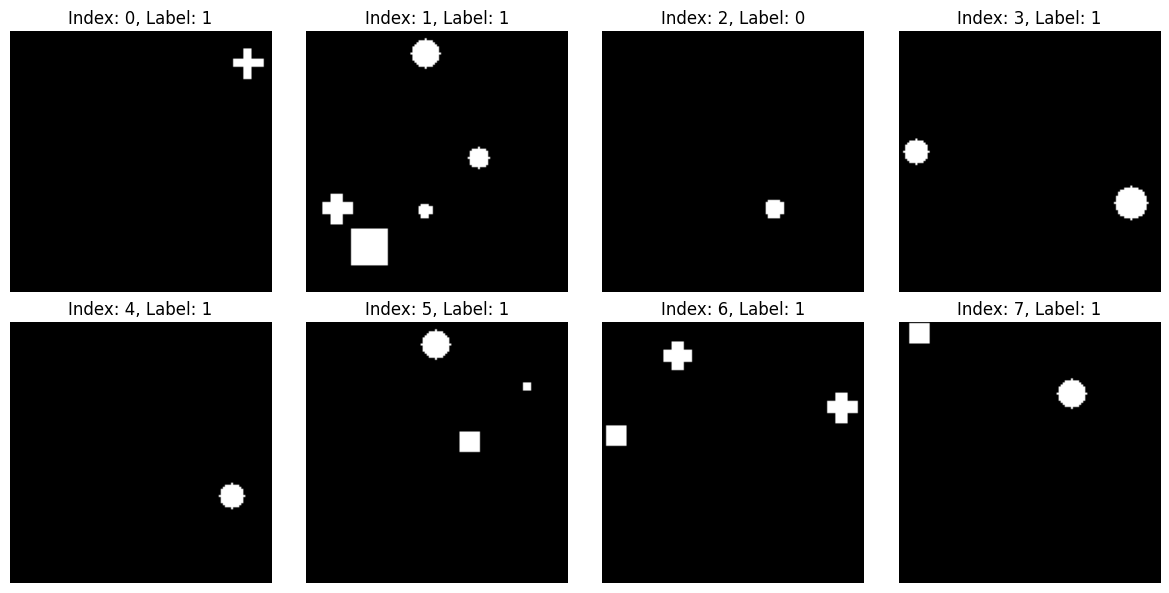


Validation set samples:


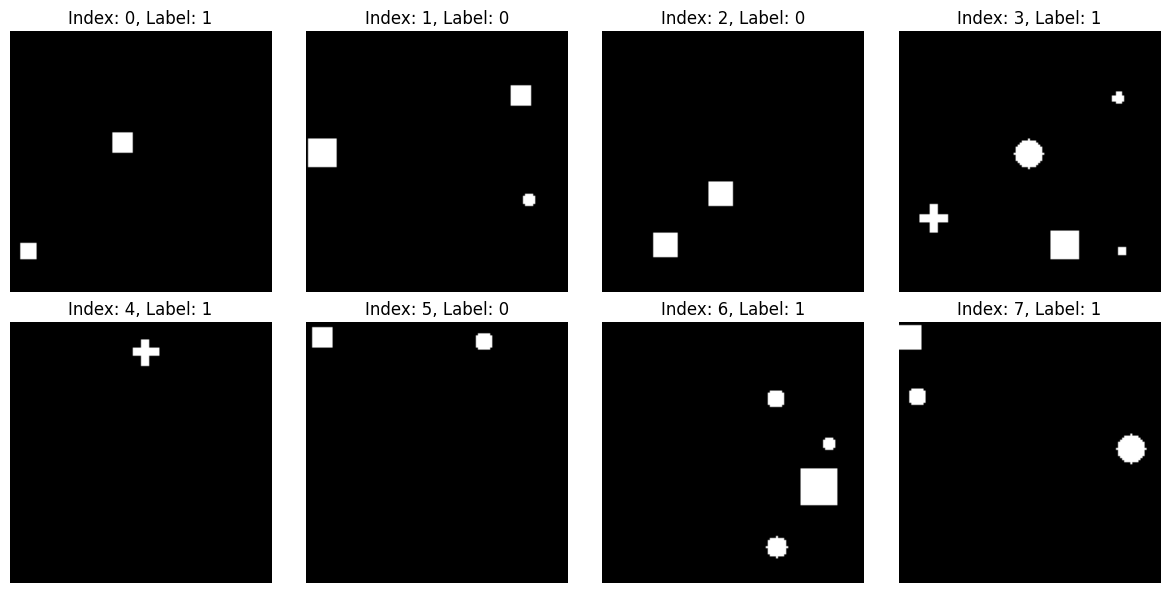


Dataset Statistics:
Training set size: 41600
Validation set size: 10400


AttributeError: 'AixiShapeDataset' object has no attribute 'labels'

In [ ]:
def show_samples(dataset, num_samples=8):
    """Display sample images from the dataset with their labels"""
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()

    for i in range(num_samples):
        
        image, label = dataset[i]

        
        img_np = image.permute(1, 2, 0).numpy()

        # Display image
        axes[i].imshow(img_np)
        axes[i].set_title(f'Index: {i}, Label: {label}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()


print("Training set samples:")
show_samples(trainset, num_samples=8)


print("\nValidation set samples:")
show_samples(valset, num_samples=8)


print(f"\nDataset Statistics:")
print(f"Training set size: {len(trainset)}")
print(f"Validation set size: {len(valset)}")


train_labels = 22
val_labels = 22

print(f"\nTraining set - Label 0: {train_labels.count(0)}, Label 1: {train_labels.count(1)}")
print(f"Validation set - Label 0: {val_labels.count(0)}, Label 1: {val_labels.count(1)}")


print(f"\nVerifying sample image paths:")
for i in [0, 1, 100]:
    img_path = f"data/aixi_shape/train/{i:05d}.png"
    exists = os.path.exists(img_path)
    print(f"Image {i:05d}.png exists: {exists}, Label: {trainset.labels[i]}")


Testing dataloader:
Batch shape: torch.Size([64, 3, 128, 128])
Batch labels: tensor([1, 1, 1, 1, 1, 1, 0, 1, 0, 0])
Labels dtype: torch.int64


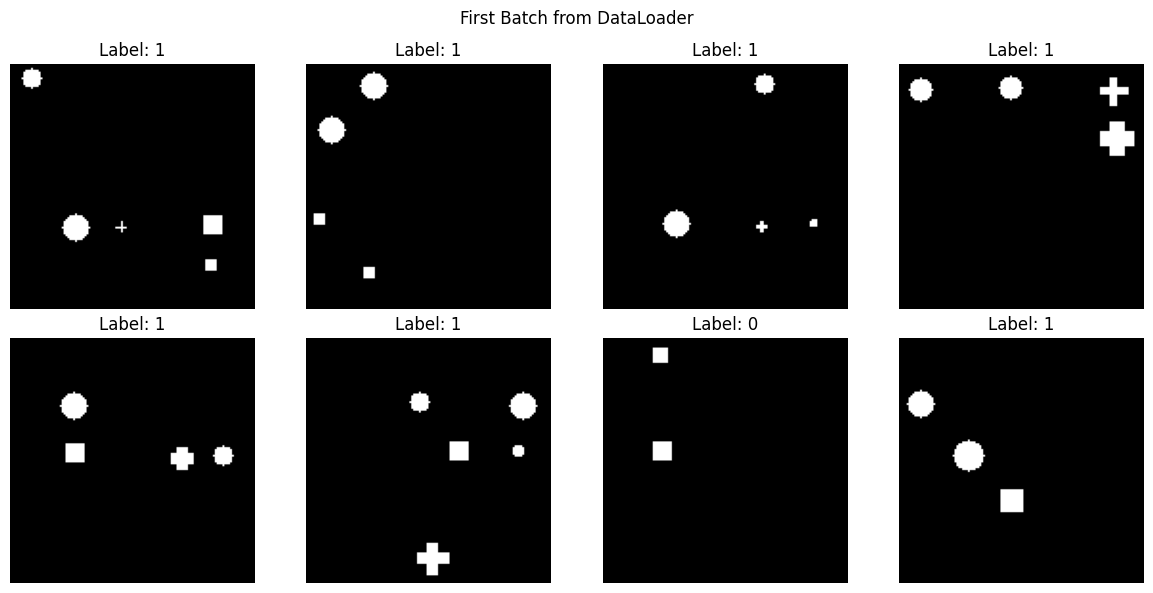

In [5]:
print("\nTesting dataloader:")
batch_images, batch_labels = next(iter(trainloader))
print(f"Batch shape: {batch_images.shape}")
print(f"Batch labels: {batch_labels[:10]}")  
print(f"Labels dtype: {batch_labels.dtype}")


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i in range(8):
    img = batch_images[i].permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(f'Label: {batch_labels[i].item()}')
    axes[i].axis('off')

plt.suptitle('First Batch from DataLoader')
plt.tight_layout()
plt.show()

In [6]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1)  

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = (outputs > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)  
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            print(loss)
            running_loss += loss.item() * inputs.size(0)
            preds = (outputs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


In [7]:
conv_depths = [
    [25, 35]
]

fc_variants = [
    [500, 250, 50],
    [1000, 500],
    [500]
]

results = []
num_epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TNet(numChannels=3,classes=1).to(device)
criterion = nn.BCELoss() 
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, trainloader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, valloader, criterion, device)
    print(f"  Epoch {epoch+1}/{num_epochs} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

# for conv_layers in conv_depths:
#     for fc_layers in fc_variants:
#         print(f"\n Training model with Conv={len(conv_layers)} layers, FC={len(fc_layers)} layers")

#         model = FlexibleTNet(
#             num_channels=3,
#             num_classes=1,   
#             conv_channels=conv_layers,
#             fc_layers=fc_layers,
#             do_sigmoid=True, 
#             size_img=128
#         ).to(device)

#         criterion = nn.BCELoss() 
#         optimizer = optim.Adam(model.parameters(), lr=1e-3)

#         for epoch in range(num_epochs):
#             train_loss, train_acc = train_one_epoch(model, trainloader, criterion, optimizer, device)
#             val_loss, val_acc = evaluate(model, valloader, criterion, device)
#             print(f"  Epoch {epoch+1}/{num_epochs} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

#         results.append({
#             "conv_layers": len(conv_layers),
#             "fc_layers": len(fc_layers),
#             "train_acc": train_acc,
#             "val_acc": val_acc
#         })

print("\nFinal Summary:")
for r in results:
    print(f"Conv={r['conv_layers']} | FC={r['fc_layers']} | Train={r['train_acc']:.3f} | Val={r['val_acc']:.3f}")

tensor(0.2216)
tensor(0.2890)
tensor(0.3567)
tensor(0.3029)
tensor(0.1846)
tensor(0.3473)
tensor(0.2095)
tensor(0.1639)
tensor(0.1444)
tensor(0.1742)
tensor(0.2534)
tensor(0.1840)
tensor(0.3739)
tensor(0.2369)
tensor(0.2466)
tensor(0.2219)
tensor(0.1708)
tensor(0.2564)
tensor(0.3048)
tensor(0.2913)
tensor(0.2693)
tensor(0.2154)
tensor(0.2618)
tensor(0.2004)
tensor(0.2643)
tensor(0.2895)
tensor(0.2501)
tensor(0.2309)
tensor(0.3042)
tensor(0.1958)
tensor(0.2767)
tensor(0.3176)
tensor(0.0941)
tensor(0.1965)
tensor(0.2825)
tensor(0.2321)
tensor(0.1577)
tensor(0.3046)
tensor(0.1580)
tensor(0.2072)
tensor(0.2582)
tensor(0.2669)
tensor(0.2114)
tensor(0.2430)
tensor(0.1699)
tensor(0.2911)
tensor(0.2775)
tensor(0.1753)
tensor(0.1974)
tensor(0.3193)
tensor(0.3079)
tensor(0.3053)
tensor(0.2564)
tensor(0.2473)
tensor(0.2257)
tensor(0.2003)
tensor(0.2759)
tensor(0.2112)
tensor(0.2331)
tensor(0.1875)
tensor(0.2631)
tensor(0.2480)
tensor(0.2166)
tensor(0.1950)
tensor(0.1234)
tensor(0.2984)
tensor(0.1

KeyboardInterrupt: 

In [ ]:
conv_depths = [
    [25],
    [25, 35],
    [25, 35, 50],
    [25, 35, 50, 75],
    [25, 35, 50, 75, 125]
]

fc_variants = [
    [500, 250, 50],
    [1000, 500],
    [500]
]

results = []
num_epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for conv_layers in conv_depths:
    for fc_layers in fc_variants:
        print(f"\n🔹 Training model with Conv={len(conv_layers)} layers, FC={len(fc_layers)} layers")

        model = FlexibleTNet(
            num_channels=3,
            num_classes=1,   # ✅ single output neuron for binary
            conv_channels=conv_layers,
            fc_layers=fc_layers,
            do_sigmoid=True,  # ✅ sigmoid at the end
            size_img=128
        ).to(device)

        criterion = nn.BCELoss()  # ✅ Binary loss
        optimizer = optim.Adam(model.parameters(), lr=1e-3)

        for epoch in range(num_epochs):
            train_loss, train_acc = train_one_epoch(model, trainloader, criterion, optimizer, device)
            val_loss, val_acc = evaluate(model, testloader, criterion, device)
            print(f"  Epoch {epoch+1}/{num_epochs} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

        results.append({
            "conv_layers": len(conv_layers),
            "fc_layers": len(fc_layers),
            "train_acc": train_acc,
            "val_acc": val_acc
        })

print("\n📊 Final Summary:")
for r in results:
    print(f"Conv={r['conv_layers']} | FC={r['fc_layers']} | Train={r['train_acc']:.3f} | Val={r['val_acc']:.3f}")
